In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from scipy.interpolate import splprep, splev
from svgpathtools import Path, CubicBezier, wsvg

import os


In [3]:
def show(img: np.ndarray):
    plt.imshow(img, cmap="gray", vmin=0, vmax=255)
    plt.axis("off")

In [4]:
def show_side_by_side_plt(images: list, labels: list = None, title="Comparison"):
    """Show a list of images side by side with matplotlib."""
    
    if labels is None:
        labels = [f"Image {i+1}" for i in range(len(images))]
    
    if len(images) != len(labels):
        raise ValueError("The number of images must match the number of labels.")
    
    num_images = len(images)
    
    
    plt.figure(figsize=(10, 5))
    
    for i, img in enumerate(images):
        plt.subplot(1, num_images, i+1)
        plt.imshow(img, cmap="gray", vmin=0, vmax=255)
        plt.title(labels[i])
        plt.axis("off")
    
    plt.suptitle(title)
    plt.show()

In [5]:
def vertical_symmetric(img: np.ndarray) -> np.ndarray:
    height, width = img.shape

    
    left_half = img[:, :width // 2]
    right_half = img[:, width // 2:]
    
    right_half_flipped = cv2.flip(right_half, 1)
    left_half_flipped = cv2.flip(left_half, 1)
    
    new_left_half = np.minimum(left_half, right_half_flipped)
    new_right_half = np.minimum(left_half_flipped, right_half)
    
    
    symmetric_image = np.hstack((new_left_half, new_right_half))
    
    return symmetric_image

In [6]:
def horizontal_symmetric(img: np.ndarray) -> np.ndarray:
    height, width = img.shape

    
    top_half = img[:height // 2, :]
    bottom_half = img[height // 2 :, :]
    
    top_half_flipped = cv2.flip(top_half, 0)
    bottom_half_flipped = cv2.flip(bottom_half, 0)
    
    new_top_half = np.minimum(top_half, bottom_half_flipped)
    new_bottom_half = np.minimum(top_half_flipped, bottom_half)
    
    
    symmetric_image = np.vstack((new_top_half, new_bottom_half))
    
    return symmetric_image

In [7]:
def centripetal_symmetric(img: np.ndarray) -> np.ndarray:
    new_img = vertical_symmetric(img)
    new_img = horizontal_symmetric(new_img)
    return new_img

In [8]:
def get_contours(img: np.ndarray):
    contours, _ = cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    contour_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    cv2.drawContours(contour_img, contours, -1, (0, 255, 0), 2)
    
    return contour_img, contours

In [9]:
def draw_quadratic_beziers_from_contours(contours, img_shape, color=(0, 0, 255), thickness=2, step=0.02):
    """
    Draws quadratic Bézier curves for each contour.
    Each curve is defined by every 3 consecutive points in the contour.

    Args:
        contours: list of contour arrays (from cv2.findContours)
        img_shape: shape of the output image (e.g. original image.shape)
        color: curve color (BGR)
        thickness: line thickness
        step: curve sampling interval (smaller = smoother)

    Returns:
        img: image with Bézier curves drawn
    """
    img = np.zeros(img_shape, dtype=np.uint8)

    for contour in contours:
        # Flatten contour shape (N,1,2) -> (N,2)
        pts = contour.reshape(-1, 2)

        # Draw each quadratic Bézier segment from 3 consecutive points
        for i in range(0, len(pts) - 2, 2):
            p0, p1, p2 = pts[i], pts[i + 1], pts[i + 2]

            # Sample curve points
            curve_points = []
            for t in np.arange(0, 1 + step, step):
                x = int((1 - t)**2 * p0[0] + 2*(1 - t)*t*p1[0] + t**2 * p2[0])
                y = int((1 - t)**2 * p0[1] + 2*(1 - t)*t*p1[1] + t**2 * p2[1])
                curve_points.append((x, y))

            # Draw polyline
            for j in range(len(curve_points) - 1):
                cv2.line(img, curve_points[j], curve_points[j + 1], color, thickness)

    return img


In [10]:
def contours_to_bezier_vectors(contours):
    """
    Convert contours (from cv2.findContours) into a list of lists of quadratic Bézier vectors.
    Each contour becomes a closed shape — last point connects back to the first.

    Each vector: ("Q", P0, P1, P2)
    """
    all_vectors = []

    for contour in contours:
        points = contour.reshape(-1, 2)
        n = len(points)
        if n < 3:
            all_vectors.append([])  # keep empty contour structure
            continue


        points = np.vstack([points, points[0]])  # connect last to first

        contour_vectors = []
        for i in range(0, len(points) - 2, 3):
            p0, p1, p2 = map(tuple, points[i:i+3])
            contour_vectors.append(("Q", p0, p1, p2))


        remain = (len(points) - 1) % 3
        if remain:
            tail = points[-3:] if len(points) >= 3 else points
            p0, p1, p2 = map(tuple, [tail[0], tail[-2], tail[-1]])
            contour_vectors.append(("Q", p0, p1, p2))

        all_vectors.append(contour_vectors)

    return all_vectors


In [11]:
def sample_bezier_vectors(all_vectors, samples_per_curve=20):
    """
    Sample a list of contours' Bézier vectors into point arrays.

    Args:
        all_vectors: list of lists of ("Q", P0, P1, P2)
        samples_per_curve: number of points per curve

    Returns:
        list of numpy arrays, one per contour
    """
    all_sampled = []

    for vectors in all_vectors:
        contour_points = []
        for cmd, p0, p1, p2 in vectors:
            if cmd != "Q":
                continue
            p0, p1, p2 = np.array(p0), np.array(p1), np.array(p2)
            t = np.linspace(0, 1, samples_per_curve)[:, None]
            curve = (1 - t)**2 * p0 + 2 * (1 - t) * t * p1 + t**2 * p2
            contour_points.append(curve)

        if contour_points:
            all_sampled.append(np.vstack(contour_points))
        else:
            all_sampled.append(np.zeros((0, 2)))

    return all_sampled


[Centripetal Catmull–Rom spline](https://en.wikipedia.org/wiki/Centripetal_Catmull%E2%80%93Rom_spline)

Vẽ hàm bậc 3 giữa các điểm của contour 

In [12]:
def smooth_contour(cnt, smooth_factor=0.2):
    cnt = cnt.squeeze()
    if not np.array_equal(cnt[0], cnt[-1]):
        cnt = np.vstack([cnt, cnt[0]])

    n = len(cnt)
    beziers = []

    for i in range(n - 1):
        p0 = cnt[i - 1].astype(float)
        p1 = cnt[i].astype(float)
        p2 = cnt[(i + 1) % n].astype(float)
        p3 = cnt[(i + 2) % n].astype(float)

        # Catmull–Rom to Cubic Bézier conversion
        c1 = p1 + (p2 - p0) * smooth_factor
        c2 = p2 - (p3 - p1) * smooth_factor

        seg = CubicBezier(
            complex(p1[0], p1[1]),
            complex(c1[0], c1[1]),
            complex(c2[0], c2[1]),
            complex(p2[0], p2[1])
        )
        beziers.append(seg)

    return Path(*beziers)


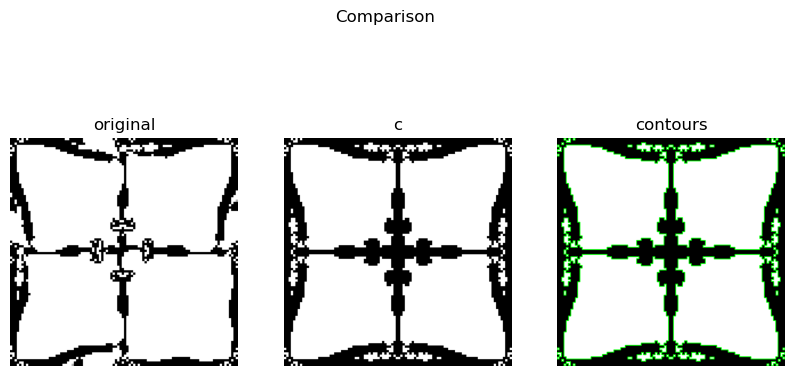

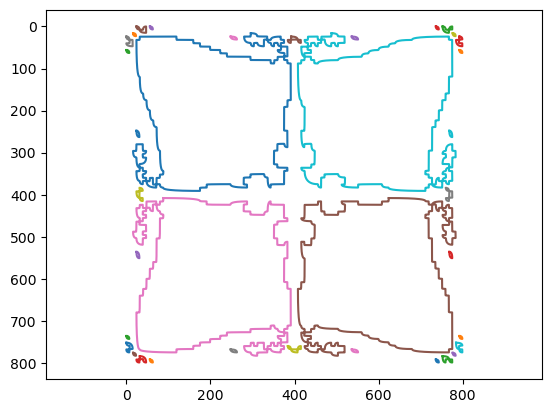

In [14]:
if __name__ == "__main__":
    img = cv2.imread("i_00043.png", cv2.IMREAD_GRAYSCALE)
    _, binary = cv2.threshold(img, 254, 255, cv2.THRESH_BINARY)

    vsymmetric = vertical_symmetric(binary)
    hsymmetric = horizontal_symmetric(binary)
    csymmetric = centripetal_symmetric(binary)
    contour_img, contours = get_contours(csymmetric)

    # show_side_by_side_plt(
    #     [img, binary, vsymmetric, hsymmetric, csymmetric, contour_img], 
    #     labels=["original", "threshold", "v", "h", "c", "contours"]
    # )

    show_side_by_side_plt(
        [img, csymmetric, contour_img], 
        labels=["original", "c", "contours"]
    )

    # paths = contours_to_quadratic_beziers(contours)
    # wsvg(paths, filename='output.svg')
    # rendered = render_svg(paths, 1080, 1080)
    # cv2.imshow("Bezier Render", rendered)
    # cv2.waitKey(0)

    all_vectors = contours_to_bezier_vectors(contours)
    all_sampled = sample_bezier_vectors(all_vectors, samples_per_curve=1000)
    for pts in all_sampled:
        plt.plot(pts[:, 0], pts[:, 1])
    plt.gca().invert_yaxis()
    plt.axis('equal')
    plt.show()




    dir = './cubic'
    if not os.path.exists(dir):
        os.makedirs(dir)

    # Ramer–Douglas–Peucker algorithm
    # epsilon lớn => các cạnh càng mượt

    # for i in range(1, 10):
    #     epsilon = i / 1000
    #     paths = []
        
    #     for cnt in contours:
    #         approx = cv2.approxPolyDP(cnt, epsilon, closed=True)
    #         path = smooth_contour(approx, smooth_factor=0.2)
    #         paths.append(path)
        
    #     filename = os.path.join(dir, f"{epsilon:.3f}.svg")
        
    #     attributes = [{'fill': 'white', 'stroke': 'none'} for _ in paths]
    #     wsvg(paths=paths, filename=filename, attributes=attributes)
        
    paths = []
    for cnt in contours:
        perimeter = cv2.arcLength(cnt, True)
        epsilon = 1
        approx = cv2.approxPolyDP(cnt, epsilon, closed=True)

        path = smooth_contour(approx, smooth_factor=0.2)
        paths.append(path)


    attributes = [{'fill': 'white', 'stroke': 'none'} for _ in paths]
    wsvg(paths=paths, filename="cubic-1.svg", attributes=attributes)
